In [2]:
#LIBRERIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize as opt

In [3]:
# PREPROCESAMIENTO
# Función para convertir variables categóricas y preparar el dataset
# Creamos categorías ordinales para Sleep_Quality
# Convertimos Stress_Level a valores numéricos
# Binarizamos Health_Issues
# Aplicamos One-Hot Encoding a Gender y convertimos otras columnas a enteros
def convertir_categoricas_for_nn(df):
    df = df.copy()
    df["Sleep_Quality"] = df["Sleep_Hours"].apply(lambda h: 0 if h < 5 else (1 if h < 6 else (2 if h < 8 else 3)))
    df["Stress_Level"] = df["Stress_Level"].map({"Low":0,"Medium":1,"High":2})
    df["Health_Issues"] = df["Health_Issues"].replace("None", 0)
    df["Health_Issues"] = df["Health_Issues"].apply(lambda x: 1 if x not in (0, "0") else 0)
    df["Gender"] = df["Gender"].fillna("Other")
    gender_dummies = pd.get_dummies(df["Gender"], prefix="Gender")
    df = pd.concat([df.drop(columns=["Gender"]), gender_dummies], axis=1)
    df["Smoking"] = df["Smoking"].astype(int)
    df["Alcohol_Consumption"] = df["Alcohol_Consumption"].astype(int)
    return df

# Estandarizamos las columnas continuas y guardamos estadísticas:
# Calculamos media y desviación estándar de cada columna
# Evitamos división por cero
# Transformamos las columnas para que tengan media 0 y desviación 1
# Guardamos las estadísticas para poder aplicar la misma transformación a otros datos
def estandarizar_continuas(X_df, columnas_continuas):
    Xs = X_df.copy()
    stats = {}
    for col in columnas_continuas:
        mean = X_df[col].mean()
        std = X_df[col].std(ddof=0)
        if std == 0: std = 1.0
        Xs[col] = (X_df[col] - mean) / std
        stats[col] = {"mean": float(mean), "std": float(std)}
    return Xs, stats



In [4]:
# FUNCIONES RED NEURONAL
# Función sigmoide
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Forward vectorizado: calculamos las activaciones de todas las capas
# a1: capa de entrada con bias
# a2: capa oculta con bias
# a3: salida
def forward_vector(theta1, theta2, X):
    m = X.shape[0]

   
    ones_input = np.ones((m,1))         
    a1 = np.hstack((ones_input, X))     
    
    
    z2 = np.dot(theta1, a1.T)          
    a2_no_bias = sigmoid(z2)          
    ones_hidden = np.ones((1, m))     
    a2 = np.vstack((ones_hidden, a2_no_bias)) 
    
    
    z3 = np.dot(theta2, a2)             
    a3 = sigmoid(z3)                    

    
    return a1, a2.T, a3.T               

# Función de coste binaria
# Calculamos la salida con forward propagation
# Aplicamos la fórmula de cross-entropy para clasificación binaria
def nnCostFunctionBinaria(nn_params, input_size, hidden_size, X, y):
    theta1 = np.reshape(nn_params[:hidden_size*(input_size+1)], (hidden_size, input_size+1), 'F')
    theta2 = np.reshape(nn_params[hidden_size*(input_size+1):], (1, hidden_size+1), 'F')
    a1, a2, h = forward_vector(theta1, theta2, X)
    h = np.clip(h, 1e-8, 1-1e-8)
    m = len(y)
    return -np.sum(y*np.log(h.flatten()) + (1-y)*np.log(1-h.flatten())) / m
    
# Cálculo del gradiente seguro
# Implementamos backpropagation de manera vectorizada
# Calculamos los deltas de cada capa y devolvemos el gradiente en un solo vector

def nnGradFunctionBinaria_safe(nn_params, input_size, hidden_size, X, y):
    theta1 = np.reshape(nn_params[:hidden_size*(input_size+1)], (hidden_size, input_size+1), 'F')
    theta2 = np.reshape(nn_params[hidden_size*(input_size+1):], (1, hidden_size+1), 'F')
    
    m = X.shape[0]
    
    a1, a2, a3 = forward_vector(theta1, theta2, X)
    d3 = a3.flatten() - y              # (m,)
    d2 = (d3[:, None] @ theta2[:,1:]) * (a2[:,1:] * (1 - a2[:,1:]))  
    
    delta1 = d2.T @ a1 / m             
    delta2 = d3[None, :] @ a2 / m      
    print("DELTA 1: ", delta1)
    print("DELTA 2: ", delta2)
    print("GRAD\n: ", np.hstack((delta1.ravel(order='F'), delta2.ravel(order='F'))))
    return np.hstack((delta1.ravel(order='F'), delta2.ravel(order='F')))
    

# Inicializamos pesos aleatoriamente para cada capa
def randInitializeWeights(L_in, L_out):
    epsilon_init = 0.12
    return np.random.rand(L_out, 1+L_in) * 2 * epsilon_init - epsilon_init

# Función para predecir con la Red Neuronal
# Calculamos forward propagation y aplicamos un umbral de 0.5 para predicción binaria
def predict(theta1, theta2, X):
    m = X.shape[0]
    ones = np.ones((m, 1))
    
    # Forward vectorizado
    a1 = np.hstack((ones, X))
    a2 = sigmoid(np.dot(a1, theta1.T))
    a2 = np.hstack((ones, a2))
    h = sigmoid(np.dot(a2, theta2.T))

    # Predicción binaria
    pred = (h.flatten() >= 0.5).astype(int)
    
    return pred, h.flatten()


# Matriz de confusión
def confusion_matrix(y_true, y_pred):
    tp = np.sum((y_true==1) & (y_pred==1))
    tn = np.sum((y_true==0) & (y_pred==0))
    fp = np.sum((y_true==0) & (y_pred==1))
    fn = np.sum((y_true==1) & (y_pred==0))
    return np.array([[tn, fp],[fn, tp]])


In [5]:
# CARGA Y PREPROCESAMIENTO
np.random.seed(42)
# Cargamos el dataset
file = pd.read_csv("synthetic_coffee_health_10000.csv", index_col=0, keep_default_na=False)

# Mostramos las primeras filas y la forma del dataframe
print("\n Dataframe completo)")
print(file.head())
print(f"\nShape: {file.shape}")

# Eliminamos columnas irrelevantes y convertimos categóricas 
file = file.drop(columns=["Country","Occupation"], errors='ignore')
file = convertir_categoricas_for_nn(file)

print("\n Dataframe traa convertir a categoricas")
print(file.head())
print(f"\nShape: {file.shape}")

# Seleccionamos las columnas que usaremos

use_cols = ["Age","Coffee_Intake","Caffeine_mg","Sleep_Hours","BMI","Heart_Rate",
            "Physical_Activity_Hours","Stress_Level","Smoking","Alcohol_Consumption"]
# Incluimos las columnas de género creadas con One-Hot Encoding
columna_genero = [c for c in file.columns if c.startswith("Gender_")]
use_cols += columna_genero

# Nos aseguramos de usar solo columnas existentes
columna_existente = [c for c in use_cols if c in file.columns]

print("Columnas x")
print(columna_existente)
# Creamos X y y
X_df = file[columna_existente].copy()
y_series = file["Health_Issues"].astype(int).copy()

print("\n x antes de escalar")
print(X_df.head())
print(f"\nShape: {X_df.shape}")


print("\n y")

print(y_series.head())
print(f"\nShape: {y_series.shape}, #1s: {sum(y_series)}, #0s: {len(y_series)-sum(y_series)}")

# Identificamos columnas continuas y las estandarizamos
continuas = [c for c in ["Age","Coffee_Intake","Caffeine_mg","Sleep_Hours","BMI",
                         "Heart_Rate","Physical_Activity_Hours"] if c in X_df.columns]

X_df, stats = estandarizar_continuas(X_df, continuas)


print("\n x despues de estandarizar")

print(X_df.head())

print("\n Estadísticas utilizadas para estandarización:")
print(stats)

# Convertimos a arrays numpy finales para el entrenamiento

X = X_df.values.astype(float)
y = y_series.values.astype(int)


print("\n Matriz final x")
print(X[:5])
print(f"Shape X = {X.shape}")







 Dataframe completo)
    Age  Gender  Country  Coffee_Intake  Caffeine_mg  Sleep_Hours  \
ID                                                                  
1    40    Male  Germany            3.5        328.1          7.5   
2    33    Male  Germany            1.0         94.1          6.2   
3    42    Male   Brazil            5.3        503.7          5.9   
4    53    Male  Germany            2.6        249.2          7.3   
5    32  Female    Spain            3.1        298.0          5.3   

   Sleep_Quality   BMI  Heart_Rate Stress_Level  Physical_Activity_Hours  \
ID                                                                         
1           Good  24.9          78          Low                     14.5   
2           Good  20.0          67          Low                     11.0   
3           Fair  22.7          59       Medium                     11.2   
4           Good  24.7          71          Low                      6.6   
5           Fair  24.1          76    

In [6]:
# HOLDOUT

m, input_size = X.shape
# Mezclamos aleatoriamente los índices de los ejemplos
perm = np.random.permutation(m)
# Separamos índices para entrenamiento (80%) y prueba (20%)
train_idx = perm[:int(0.8*m)]
test_idx = perm[int(0.8*m):]
# Creamos los conjuntos de entrenamiento y prueba
X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]


In [7]:
# INICIALIZACIÓN
# Definimos el tamaño de la capa oculta
hidden_size = 20
# Creamos pesos aleatorios para conectar la capa de entrada con la capa oculta y la capa oculta con la de salida
Theta1_init = randInitializeWeights(input_size, hidden_size)
Theta2_init = randInitializeWeights(hidden_size, 1)
# Aplanamos y unimos todos los pesos en un solo vector para usarlos en la optimización
initial_nn_params = np.hstack((Theta1_init.ravel(order='F'), Theta2_init.ravel(order='F')))



In [8]:
# ENTRENAMIENTO
# Creamos una lista para ir guardando el historial del coste durante el entrenamiento
cost_history = []
# Función callback que calcula y guarda el coste cada vez que se actualizan los pesos
def callback_nn(p):
    J = nnCostFunctionBinaria(p, input_size, hidden_size, X_train, y_train)
    cost_history.append(J)


print("Entrenando red neuronal...\n")
maxiter = 50  

# Entrenamos la red neuronal usando el método de gradiente conjugado
nn_params = opt.fmin_cg(
    f=nnCostFunctionBinaria,                    
    x0=initial_nn_params,                       
    fprime=nnGradFunctionBinaria_safe,          
    args=(input_size, hidden_size, X_train, y_train), 
    callback=callback_nn,
    maxiter=maxiter,
    disp=True
)

# Separamos los pesos entrenados para cada capa
Theta1 = np.reshape(nn_params[:hidden_size * (input_size + 1)],
                    (hidden_size, input_size + 1), order='F')
Theta2 = np.reshape(nn_params[hidden_size * (input_size + 1):],
                    (1, hidden_size + 1), order='F')



Entrenando red neuronal...

DELTA 1:  [[ 1.32208583e-03 -9.99093533e-04 -4.68513453e-04 -4.69717528e-04
   2.70150571e-03 -6.78097036e-04 -1.11234983e-04  4.55262871e-06
  -1.67937522e-03  2.88810481e-04  4.27155589e-04  6.53250470e-04
   6.41793340e-04  2.70420152e-05]
 [ 3.93335009e-03 -2.94805983e-03 -1.32906308e-03 -1.33250085e-03
   7.82224280e-03 -2.05477763e-03 -3.23125426e-04  1.05874808e-05
  -4.79036379e-03  8.51941200e-04  1.25945350e-03  1.94076793e-03
   1.91255393e-03  8.00282250e-05]
 [ 3.67123598e-03 -2.77341863e-03 -1.25392585e-03 -1.25713673e-03
   7.37944621e-03 -1.92608205e-03 -3.20070608e-04  1.90052110e-05
  -4.54256974e-03  7.94827748e-04  1.18091674e-03  1.81535663e-03
   1.78129045e-03  7.45888985e-05]
 [ 2.47792160e-03 -1.88189448e-03 -8.27601170e-04 -8.29817571e-04
   4.96588837e-03 -1.28292745e-03 -2.04546768e-04  1.23553613e-05
  -3.05767478e-03  5.35122779e-04  7.96065723e-04  1.22049805e-03
   1.20679082e-03  5.06327392e-05]
 [ 1.91535517e-03 -1.45236304e

C:\Users\aleja\anaconda3\envs\entornoIA2425\lib\site-packages\scipy\optimize\_optimize.py:1659: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_cg(f, x0, args, fprime, callback=callback, c1=c1, c2=c2,


In [9]:
# EVALUACIÓN
# Hacemos predicciones sobre los conjuntos de entrenamiento y prueba
train_preds, train_probs = predict(Theta1, Theta2, X_train)
test_preds, test_probs = predict(Theta1, Theta2, X_test)

# Calculamos la precisión en entrenamiento y prueba
train_acc = np.mean(train_preds == y_train)
test_acc = np.mean(test_preds == y_test)
print(f"Train accuracy: {train_acc*100:.2f}%")
print(f"Test accuracy: {test_acc*100:.2f}%")

# Calculamos y mostramos la matriz de confusión para el conjunto de prueba
cm_test = confusion_matrix(y_test, test_preds)
print("Confusion matrix (test):\n", cm_test)


Train accuracy: 99.44%
Test accuracy: 99.20%
Confusion matrix (test):
 [[1184    8]
 [   8  800]]


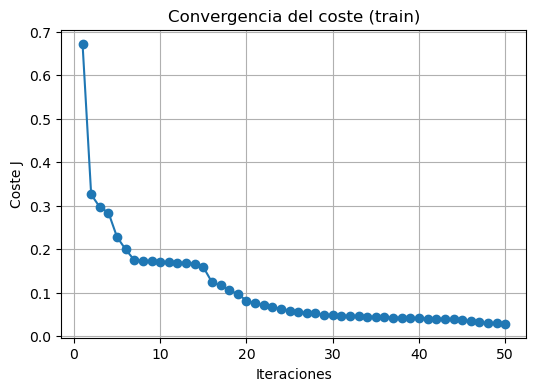

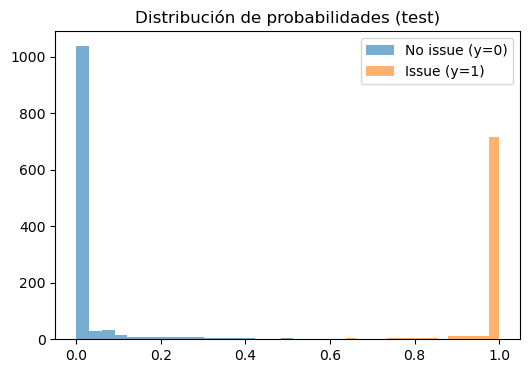

In [10]:
# GRÁFICOS
plt.figure(figsize=(6,4))
plt.plot(range(1,len(cost_history)+1), cost_history, marker='o')
plt.xlabel("Iteraciones")
plt.ylabel("Coste J")
plt.title("Convergencia del coste (train)")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.hist(test_probs[y_test==0], bins=30, alpha=0.6, label="No issue (y=0)")
plt.hist(test_probs[y_test==1], bins=30, alpha=0.6, label="Issue (y=1)")
plt.legend()
plt.title("Distribución de probabilidades (test)")
plt.show()